# PRÁTICA 1 — Extração de Dados dos artigos do STIL

**Grupo 6** · STIL 2017 · 31 artigos

`PDF → Markdown → texto limpo → partes (resumo/corpo/referências) → tokens/POS/lema → estatísticas → JSON`

Cada seção abaixo é uma etapa da pipeline e responde uma pergunta. A implementação fica em `ml/`.

## 0. Setup

- **Local:** já existe o `.venv` (via `uv sync`) e o kernel **`Python (pratica-1-stil)`** — selecione ele no notebook.
- **Colab:** sobe a pasta `pratica-1-stil` (`notebook.ipynb` + `ml/`). A célula abaixo instala as deps e cada etapa da pipeline **roda de verdade**. Se o arquivo já existir, ela não baixa/processa de novo.

O `corpus/` não vai no git: no Colab ele é gerado do zero (PDFs do SOL/SBC → markdown → JSON).

In [2]:
import json
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
PKGS = [
    "requests",
    "beautifulsoup4",
    "firecrawl-anydoc",
    "pymupdf4llm",
    "spacy>=3.8,<3.9",
    "langdetect",
    "wordcloud",
    "matplotlib",
]
MODELOS = {
    "pt_core_news_sm": "https://github.com/explosion/spacy-models/releases/download/pt_core_news_sm-3.8.0/pt_core_news_sm-3.8.0-py3-none-any.whl",
    "en_core_web_sm": "https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl",
}


def _pip(*args: str) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])


def ensure_project() -> Path:
    if Path("ml/baixar.py").exists():
        return Path.cwd().resolve()
    if Path("pratica-1-stil/ml/baixar.py").exists():
        os.chdir("pratica-1-stil")
        return Path.cwd().resolve()
    raise FileNotFoundError("pasta ml/ não encontrada — suba o notebook junto com a pasta ml/")


ROOT = ensure_project()
sys.path.insert(0, str(ROOT))
CORPUS = ROOT / "corpus"

if IN_COLAB:
    _pip(*PKGS)
    import importlib.util

    faltando = [url for nome, url in MODELOS.items() if importlib.util.find_spec(nome) is None]
    if faltando:
        _pip(*faltando)

print("projeto:", ROOT)
print("colab:", IN_COLAB)
print("corpus:", CORPUS, "(existe)" if CORPUS.exists() else "(ainda não — a próxima célula baixa)")

## 1. Baixar — de onde vêm os PDFs e os metadados?

Fonte: anais do **STIL 2017** no **SOL/SBC** (OJS) - 262. O `ml/baixar.py` lê a página da issue, pega os metadados (`citation_*`) e baixa os PDFs.

Cada artigo ganha um número na ordem dos anais: `corpus/files/article_01.pdf` … `article_31.pdf`.

Se `artigos.json` e os PDFs já estiverem lá, **não baixa de novo**.

In [3]:
from ml import baixar

baixar.run()  # pula se artigos.json + PDFs já existirem

meta = json.loads((CORPUS / "data" / "artigos.json").read_text())
print(len(meta), "artigos\n")
for m in meta[:3]:
    print(m["ordem"], "|", m["titulo"][:55], "|", m["autores"][0]["nome"], "|", m["storage_key"])

31 artigos

1 | Uma​ ​Ferramenta​ ​para​ ​Identificar​ ​Desvios​ ​de​ ​ | Jonathan​ ​Nau​ | corpus/files/article_01.pdf
2 | Estudo exploratório de categorias gramaticais com poten | Júlia Santos Nunes Rodrigues | corpus/files/article_02.pdf
3 | Geração de perguntas e respostas para a base de conheci | Joyce Martins | corpus/files/article_03.pdf


## 2. Ler — como o PDF vira texto?

`ml/ler.py` usa o **anydoc** (PDF → Markdown). Quando ele recusa uma página pedindo OCR, cai no **pymupdf4llm** local — aconteceu em 3 artigos.

Converte só o que ainda não tem `corpus/text/article_NN.md`.

In [4]:
from ml import ler

ler.run()  # pula .md que já existem

md_texto = (CORPUS / "text" / "article_01.md").read_text()
print(md_texto[:600])

método: pymupdf4llm
Proceedings of Symposium in Information and Human Language Technology. Uberlˆandia, MG, Brazil, October 2–5, 2017. _<u>⃝</u>_ c 2017 Sociedade Brasileira de Computac¸˜ao. 

# **Uma** ​ ​ **Ferramenta** ​ ​ **para** ​ ​ **Identificar** ​ ​ **Desvios** ​ ​ **de** ​ ​ **Linguagem** ​ ​ **na Língua** ​ ​ **Portuguesa** 

**Jonathan** ​ ​ **Nau** ​<sup>**1**​</sup> ,​ **​ Aluizio** ​ ​ **Haendchen** ​ ​ **Filho** ​<sup>**1**​</sup> **,** ​ ​ **Guilherme** ​ ​ **Passero** ​<sup>**1,2**​</sup> **,** ​ ​ **Vinicius** ​ ​ **Cavaco** ​<sup>**1**</sup> 

> 1​Núcleo​ ​de​ ​Inteligência​ ​Artificial​ ​e​ ​


## 3. Limpar — o que sai e o que fica

- **Sai:** cabeçalho/rodapé repetido, mojibake dos acentos, zero-width, tags HTML, ênfase do markdown.
- **Fica:** os headings (`#`), porque a próxima etapa usa as seções pra separar as partes.

Gera `corpus/text/limpo/` só para o que ainda não foi limpo.

In [5]:
from ml import limpar

limpar.run()  # pula limpo/ que já existe

cru = (CORPUS / "text" / "article_01.md").read_text()
limpo = (CORPUS / "text" / "limpo" / "article_01.md").read_text()
print("--- cru ---");   print(cru[:260])
print("--- limpo ---"); print(limpo[:260])

--- cru ---
Proceedings of Symposium in Information and Human Language Technology. Uberlˆandia, MG, Brazil, October 2–5, 2017. _<u>⃝</u>_ c 2017 Sociedade Brasileira de Computac¸˜ao. 

# **Uma** ​ ​ **Ferramenta** ​ ​ **para** ​ ​ **Identificar** ​ ​ **Desvios** ​ ​ **de*
--- limpo ---
# Uma Ferramenta para Identificar Desvios de Linguagem na Língua Portuguesa
Jonathan Nau 1 , Aluizio Haendchen Filho 1 , Guilherme Passero 1,2 , Vinicius Cavaco 1
> 1Núcleo de Inteligência Artificial e Sistemas Inteligentes (NIASI) Centro Universitário de Brus


## 4. Separar — as partes do artigo

`ml/separar.py` acha o **resumo**, o **corpo** e as **referências**. Regra da tarefa: referências e autores entram no JSON mas **não** são processados.

Monta `corpus/json/article_NN.json` só se ainda não existir.

In [6]:
from ml import separar

separar.run()  # pula JSON que já existe

d = json.loads((CORPUS / "json" / "article_01.json").read_text())
print("resumo:", len(d["resumo"]), "chars")
print("corpo (artigo_completo):", len(d["artigo_completo"]), "chars")
print("referências:", len(d["referencias"]), "| exemplo:", d["referencias"][0][:60])
print("\n--- início do corpo ---")
print(d["artigo_completo"][:300])

resumo: 525 chars
corpo (artigo_completo): 10477 chars
referências: 15 | exemplo: Belinky, T. (2010) Cacoliques, Editora Melhoramentos

--- início do corpo ---
The revision of formal texts is a complex task and occurs in several areas. The objective of this work is to create a tool to support the revision of texts and promote studies in automatic correction of descriptive texts. We propose a reviewer for automatic identification of language deviations in f


## 5. Processar — tokens, POS, lemas e keywords

`ml/processar.py` detecta o idioma (`langdetect`) e passa o texto no **spaCy** (`pt_core_news_sm` ou `en_core_web_sm`). Stopwords ficam (regra da tarefa).

**Keywords:** o SOL e o PDF do STIL 2017 não têm o campo. Extraímos sintagmas nominais do **título** (prioridade) e do **resumo**.

Se o JSON já tiver tokens e keywords, não processa de novo.

In [7]:
from ml import processar

processar.run()  # pula se já tem tokens e keywords

d = json.loads((CORPUS / "json" / "article_01.json").read_text())
print("idioma:", d["idioma"], "| tokens:", len(d["artigo_tokenizado"]))
print("keywords:", d["keywords"])
print(f"{'token':<16}{'pos':<10}lema")
for tok, pos, lema in list(zip(d["artigo_tokenizado"], d["pos_tagger"], d["lema"]))[:10]:
    print(f"{tok:<16}{pos:<10}{lema}")

idioma: pt | tokens: 1561
token           pos       lema
The             PROPN_The The
revision        PROPN_revisionrevision
of              PROPN_of  of
formal          ADJ_formalformal
texts           PROPN_textstexts
is              PROPN_is  is
a               DET_a     o
complex         PROPN_complexcomplex
task            PROPN_tasktask
and             PROPN_and and


## 6. Contar — o retrato do corpus

`ml/contar.py` junta os 31 artigos. A regra é **não remover stopwords**; a versão sem stopwords existe só pra comparar.

As nuvens são **4**: pt/en × com/sem stopwords. Estatísticas e PNGs só são gerados se ainda não existirem.

In [8]:
from ml import contar

contar.run()  # pula se estatisticas.json já existir

stats = json.loads((CORPUS / "estatisticas.json").read_text())
print(stats["corpus"])
print("\nTop 10 palavras (regra):   ", stats["com_stopwords"]["top10_palavras"])
print("Top 10 substantivos:      ", stats["com_stopwords"]["top10_substantivos"])
print("Top 10 verbos:            ", stats["com_stopwords"]["top10_verbos"])
print("\nTop 10 palavras (sem stop):", stats["sem_stopwords"]["top10_palavras"])

{'artigos': 31, 'tokens': 83515, 'types': 13085, 'sentencas': 4140, 'lemas_unicos': 10862}

Top 10 palavras (regra):    [['a', 2042], ['the', 1604], ['e', 1569], ['o', 1389], ['que', 1099], ['and', 665], ['uma', 651], ['um', 642], ['os', 579], ['as', 546]]
Top 10 substantivos:       [['corpus', 201], ['base', 172], ['palavras', 162], ['dados', 162], ['termos', 143], ['construções', 129], ['trabalho', 128], ['exemplo', 122], ['texto', 119], ['construção', 111]]
Top 10 verbos:             [['used', 101], ['pode', 81], ['using', 76], ['podem', 66], ['apresenta', 56], ['tem', 52], ['partir', 49], ['identificar', 41], ['seja', 41], ['há', 38]]

Top 10 palavras (sem stop): [['al', 277], ['et', 272], ['1', 265], ['corpus', 228], ['2', 195], ['base', 186], ['dados', 165], ['palavras', 163], ['3', 156], ['termos', 144]]


nuvem_pt_com_stopwords.png


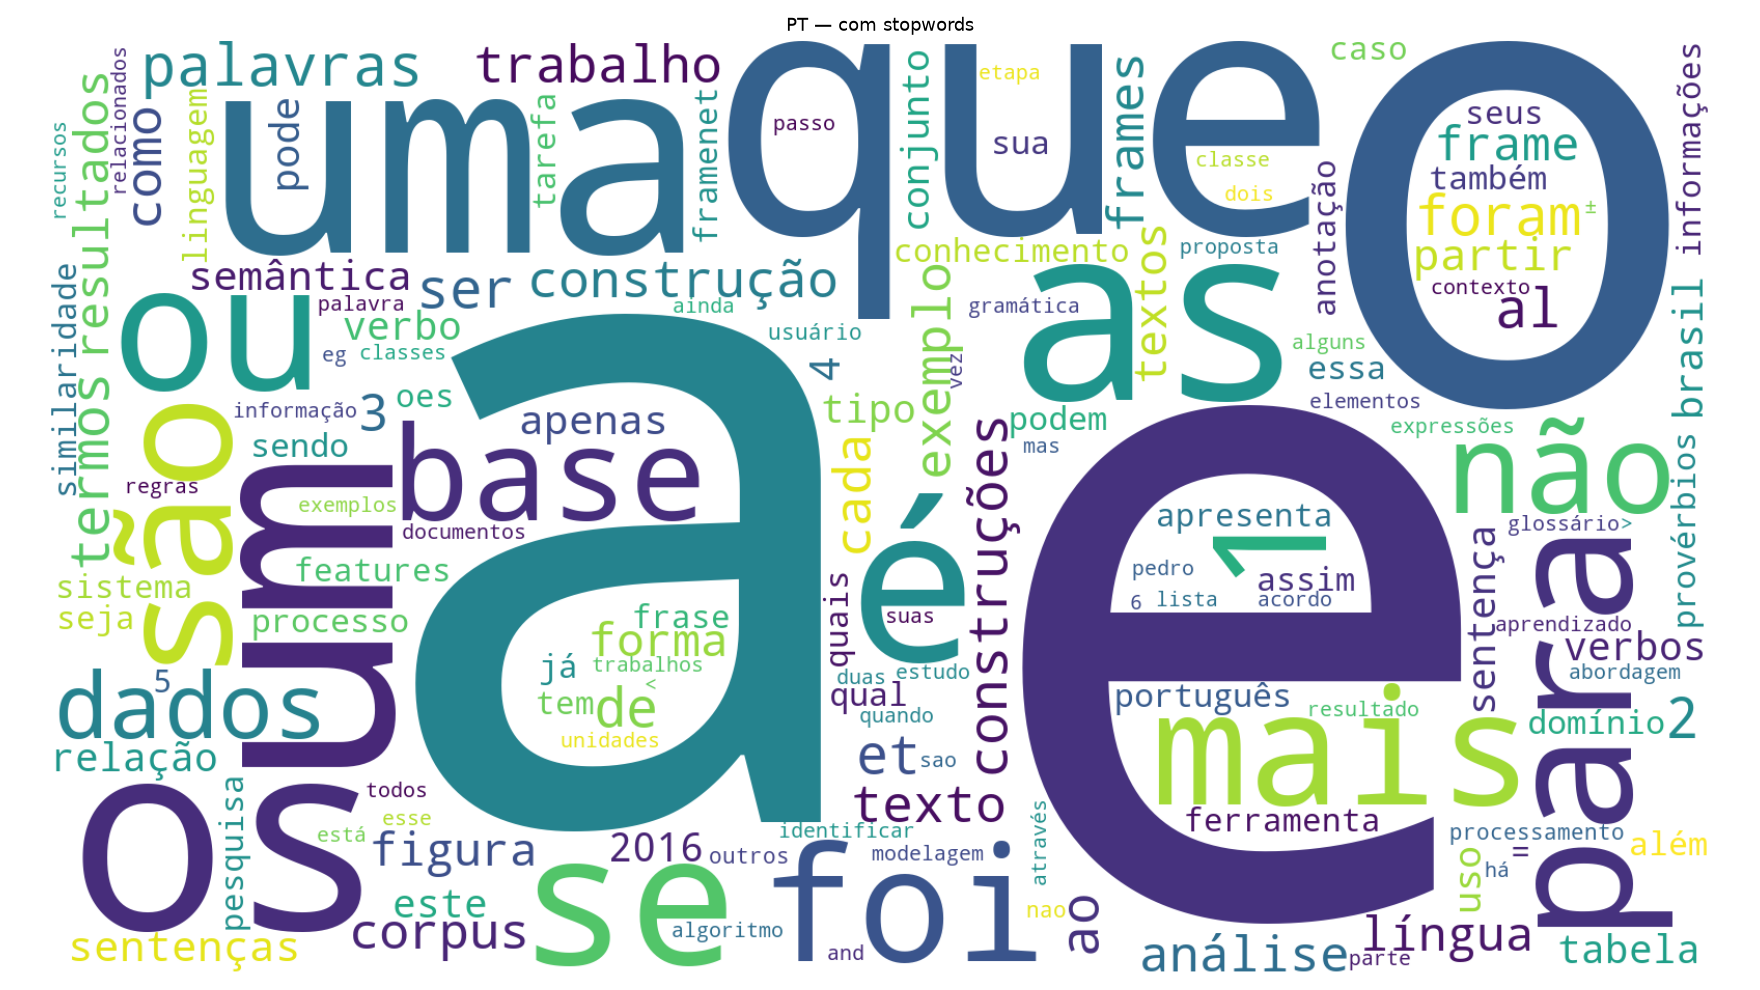

nuvem_pt_sem_stopwords.png


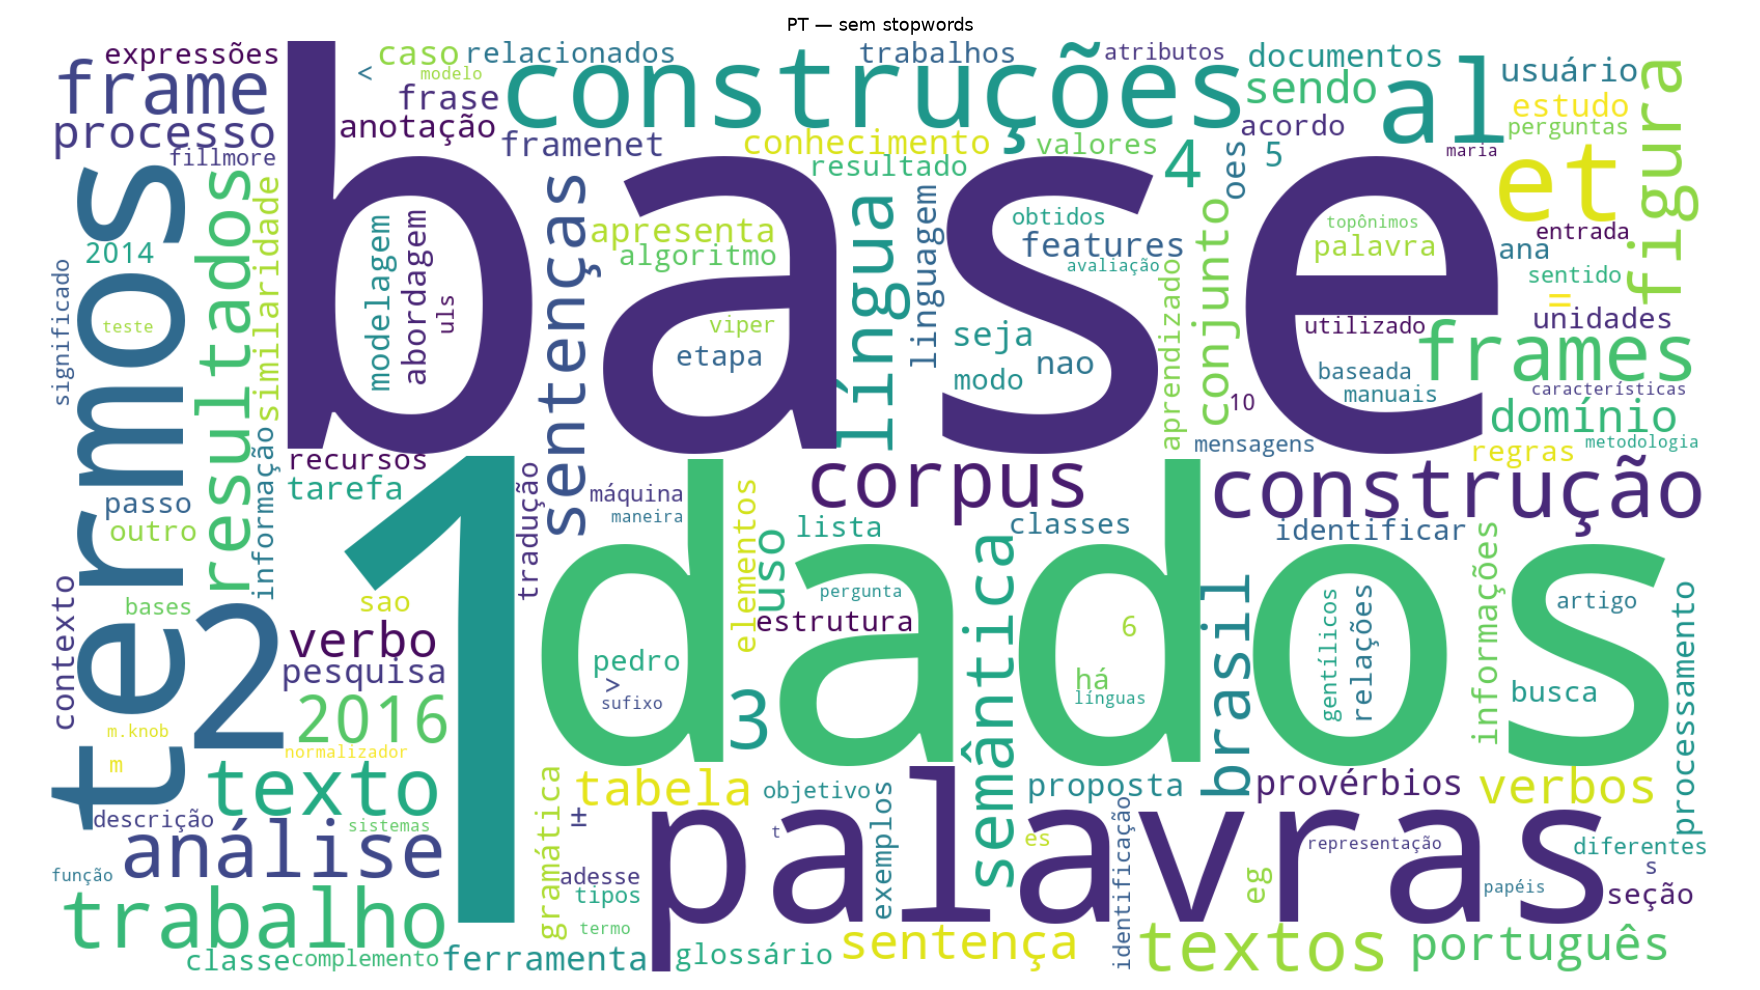

nuvem_en_com_stopwords.png


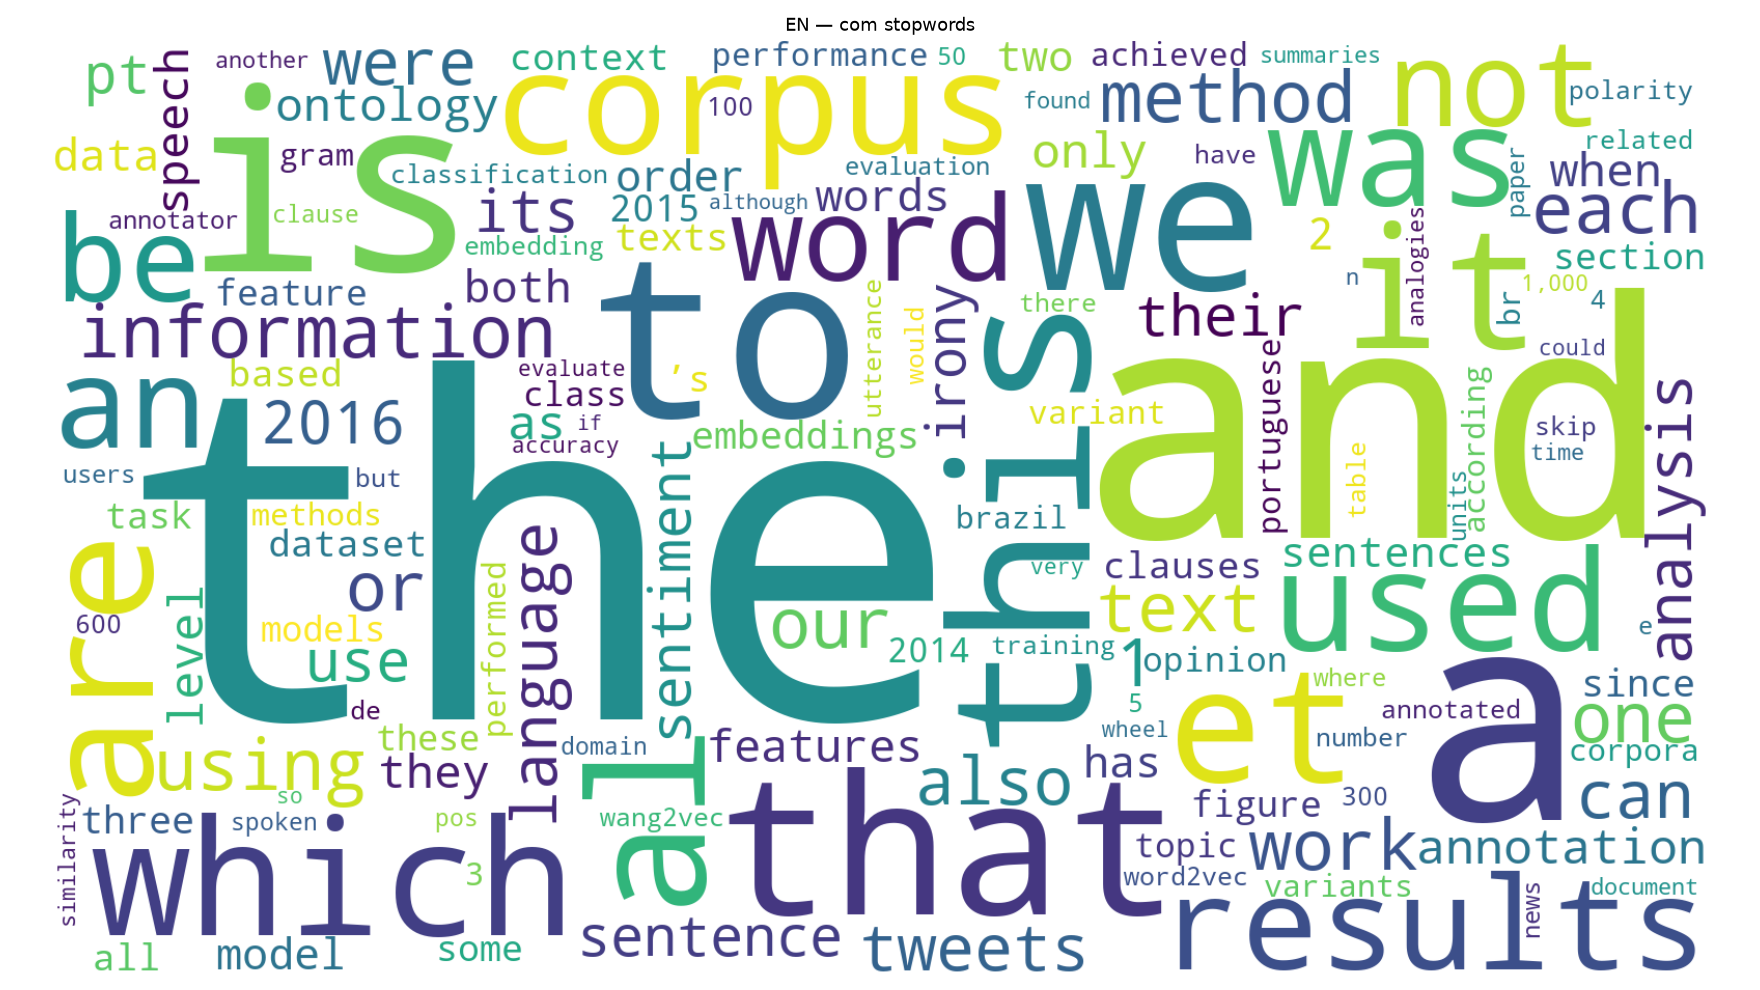

nuvem_en_sem_stopwords.png


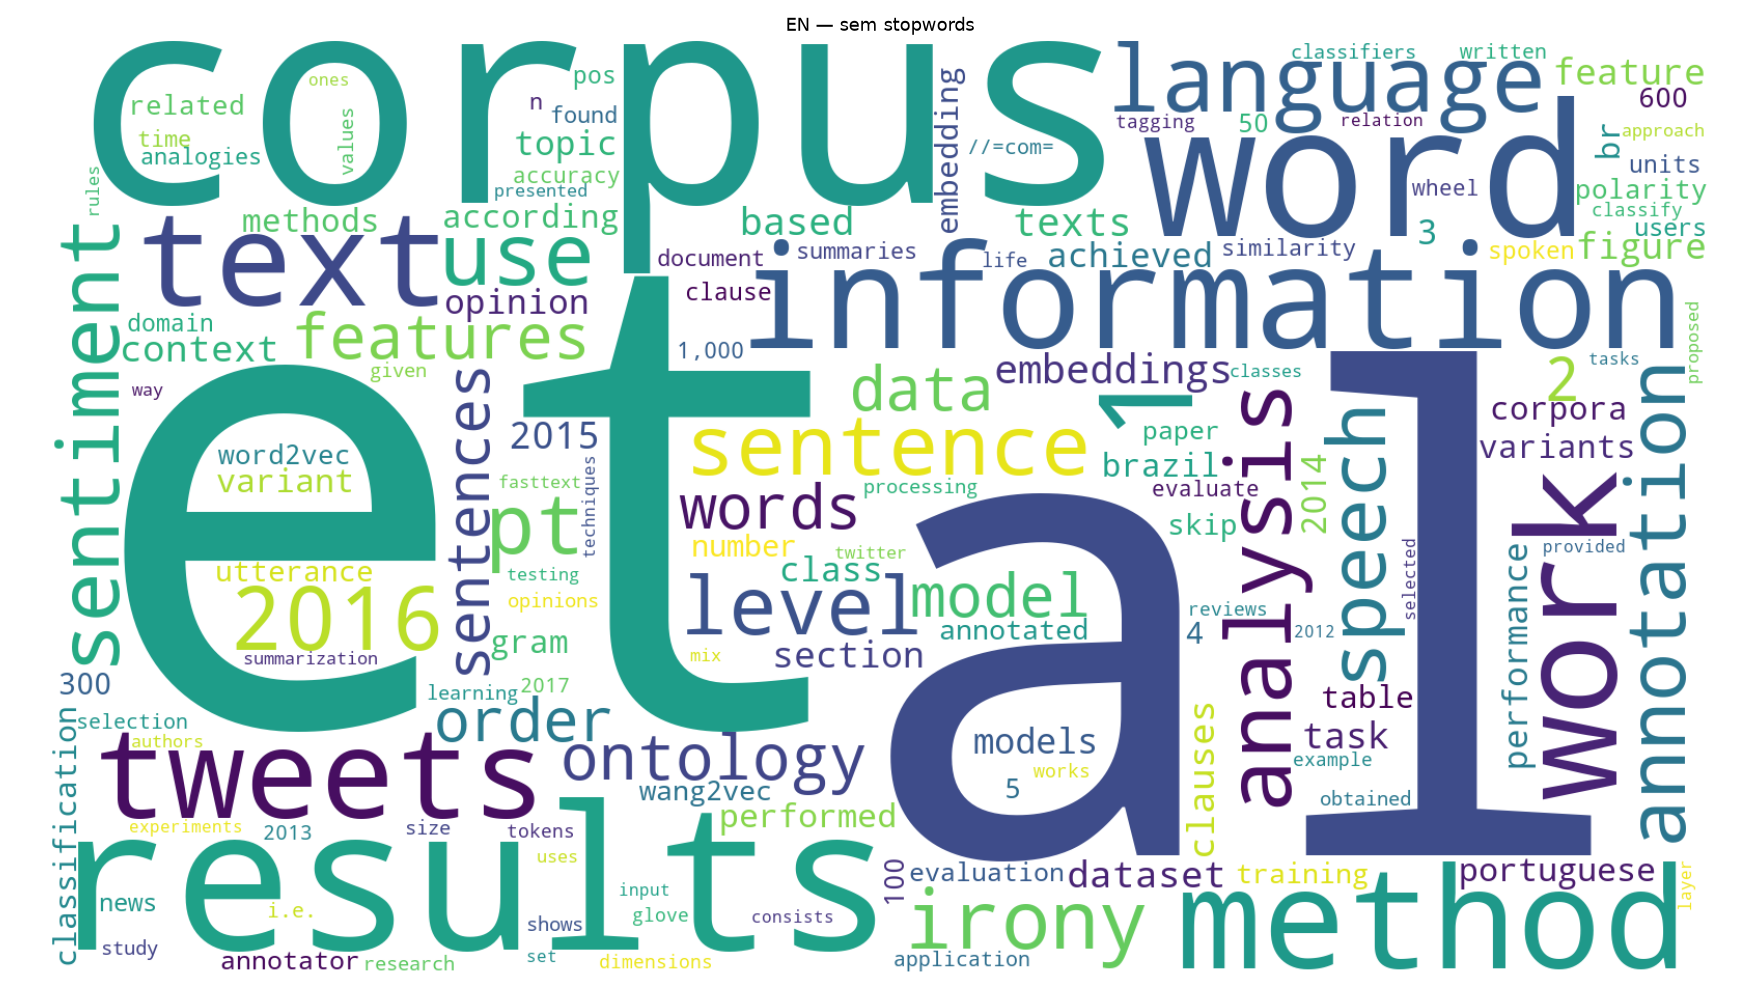

In [9]:
from IPython.display import Image, display

artigos = contar.carregar()
for idioma in ("pt", "en"):
    for sem in (False, True):
        suf = "sem" if sem else "com"
        destino = CORPUS / f"nuvem_{idioma}_{suf}_stopwords.png"
        if not destino.exists():
            freq = contar.frequencias(artigos, idioma=idioma, sem_stopwords=sem)
            contar.nuvem(freq, destino, f"{idioma.upper()} — {suf} stopwords")
        print(destino.name)
        display(Image(filename=str(destino)))

## 7. Salvar — o JSON final

Um JSON por artigo, em `corpus/json/article_NN.json`, no template do professor.

In [10]:
amostra = {k: (v[:3] if isinstance(v, list) else v) for k, v in d.items()}
print(json.dumps(amostra, ensure_ascii=False, indent=2)[:1100])
print("\nsaídas em corpus/:")
for p in sorted(CORPUS.iterdir()):
    print(" ", p.name)

{
  "titulo": "Uma Ferramenta para Identificar Desvios de Linguagem na Língua Portuguesa",
  "informacoes_url": "https://sol.sbc.org.br/index.php/stil/article/view/4007",
  "idioma": "pt",
  "storage_key": "corpus/files/article_01.pdf",
  "autores": [
    {
      "nome": "Jonathan Nau",
      "afiliacao": "UNIFEBE"
    },
    {
      "nome": "Aluizio Haendchen Filho",
      "afiliacao": "UNIFEBE"
    },
    {
      "nome": "Guilherme Passero",
      "afiliacao": "UNIFEBE / UNIVALI"
    }
  ],
  "data_publicacao": "2017/10/02",
  "resumo": "The revision of formal texts is a complex task and occurs in several areas. The objective of this work is to create a tool to support the revision of texts and promote studies in automatic correction of descriptive texts. We propose a reviewer for automatic identification of language deviations in formal descriptive texts using natural language processing techniques. A case study was carried out to evaluate the proposed approach in a public set of es

## De onde vem cada campo do JSON

| Campo | Etapa | Fonte |
|---|---|---|
| `titulo`, `informacoes_url`, `storage_key`, `autores`, `data_publicacao` | 1 | metadados do SOL |
| `resumo` | 1 | abstract do SOL |
| `idioma` | 5 | `langdetect` sobre o corpo |
| `keywords` | 5 | sintagmas nominais do título + resumo (SOL/PDF não trazem) |
| `referencias` | 4 | extraídas do texto; **não** processadas |
| `artigo_completo` | 4 | resumo + corpo (sem autores/referências) |
| `artigo_tokenizado`, `pos_tagger`, `lema` | 5 | spaCy |